In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from joblib import load

# --- Paths ---
MODELS_DIR = Path("../../../data/out/best_models_ml/validation_ml/models")
PRED_DIR   = Path("../../../data/out/best_models_ml/validation_ml/predictions")
PLOTS_DIR  = Path("../../../data/out/best_models_ml/validation_ml/plots")
PLOTS_CUSTOM = Path("../../../data/out/best_models_ml/validation_ml/plots_custom")
PLOTS_CUSTOM.mkdir(parents=True, exist_ok=True)

C:\Users\Camilo\AppData\Local\Temp\ipykernel_30520\3357522918.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  fechas = pd.date_range(start="2025-07-01 00:00", periods=n, freq="H")


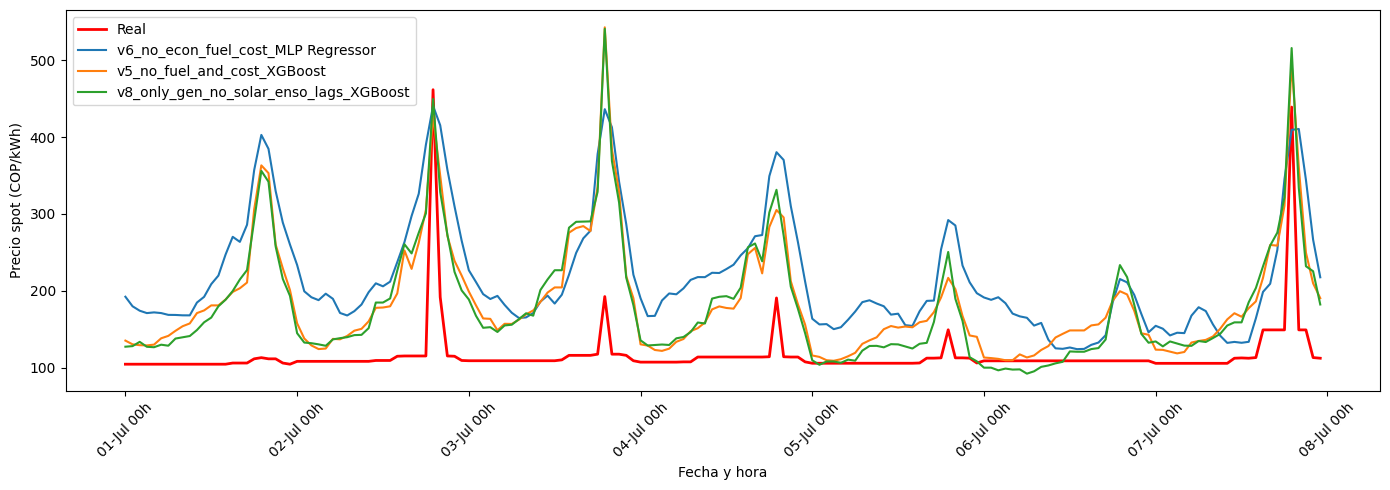

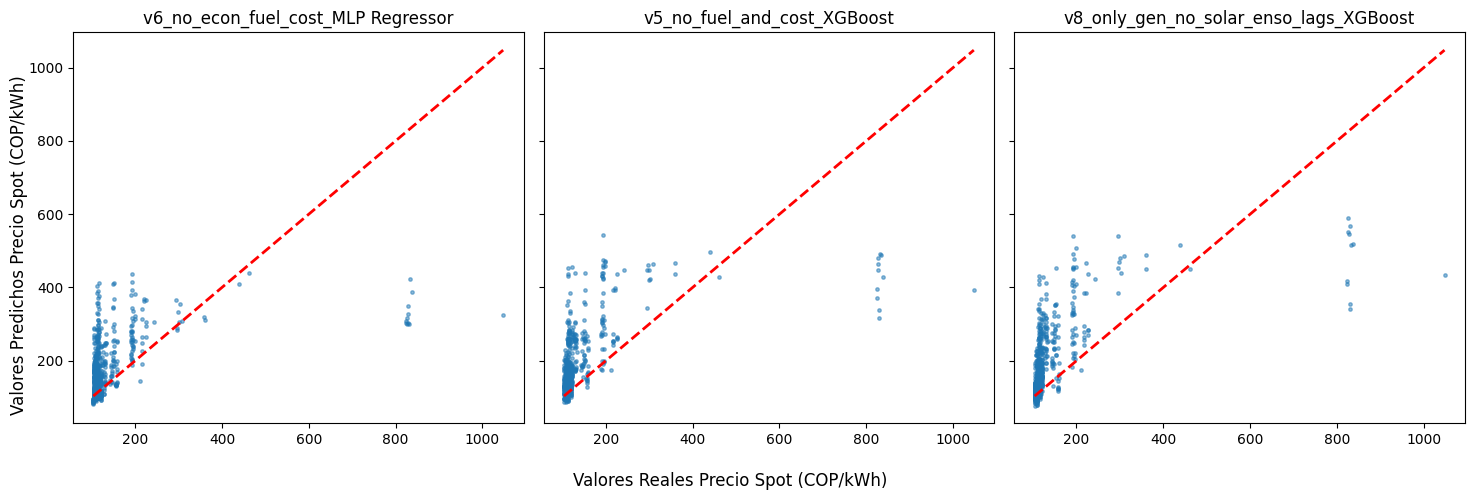

In [9]:
# --- Dataset de validación externo ---
df_val = pd.read_csv("../../../data/out/dataset_validation_final.csv")
X_val = df_val.drop(columns=["PRECIO", "FECHA_HORA"])
y_val = df_val["PRECIO"]

# --- Configuración ---
n = len(y_val)
n_observations = 24 * 7  # 7 días de observaciones
fechas = pd.date_range(start="2025-07-01 00:00", periods=n, freq="H")

# --- Selección de los tres mejores modelos ---
top_models = [
    ("v6_no_econ_fuel_cost", "MLP Regressor"),
    ("v5_no_fuel_and_cost", "XGBoost"),
    ("v8_only_gen_no_solar_enso_lags", "XGBoost")
]

predicciones = {}

for variant, config_name in top_models:
    model_file = MODELS_DIR / f"{variant}_{config_name}.joblib"
    pipe = load(model_file)
    y_pred = pipe.predict(X_val)
    predicciones[f"{variant}_{config_name}"] = y_pred

# ----------------------------------------------------------------------
# 1. Predicciones vs reales (Top 3 en una sola gráfica)
plt.figure(figsize=(14,5))
plt.plot(fechas[:n_observations], y_val.values[:n_observations],
         label="Real", color="red", linewidth=2)

for name, y_pred in predicciones.items():
    plt.plot(fechas[:n_observations], y_pred[:n_observations], label=name)

plt.xlabel("Fecha y hora")
plt.ylabel("Precio spot (COP/kWh)")
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%b %Hh"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(PLOTS_CUSTOM / "pred_top3_ml.png")
plt.show()
plt.close()

# ----------------------------------------------------------------------
# 2. Scatter (Top 3 en una sola gráfica)
fig, axes = plt.subplots(1, 3, figsize=(15,5), sharex=True, sharey=True)

lims = [y_val.min(), y_val.max()]

for ax, (name, y_pred) in zip(axes, predicciones.items()):
    ax.scatter(y_val, y_pred, s=6, alpha=0.5)
    ax.plot(lims, lims, 'r--', linewidth=2)
    ax.set_title(name)

# Una sola etiqueta global para X e Y
fig.supxlabel("Valores Reales Precio Spot (COP/kWh)")
fig.supylabel("Valores Predichos Precio Spot (COP/kWh)")

plt.tight_layout()


plt.savefig(PLOTS_CUSTOM / "scatter_top3_ml.png")
plt.show()
plt.close()
